<a href="https://colab.research.google.com/github/willbueno/VWCO-Curso-IA/blob/main/1%20-%20EDA/%5BExtra%5DClusteriza%C3%A7%C3%A3o.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Importando as bibliotecas



In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

Carregando os dados do CSV que está no Github

In [3]:
data = pd.read_csv('https://raw.githubusercontent.com/TreinamentoICCInatel/CursoVW/refs/heads/main/EDA/Auto%20Sales%20data.csv')

Criando um novo DataFrame (rfm) agrupado por CUSTOMERNAME e agregado com as outras 3 colunas - dias, frequência e valor total de pedidos.

In [4]:
rfm = (
    data.groupby("CUSTOMERNAME")
    .agg(
        {
            "DAYS_SINCE_LASTORDER": "min",
            "ORDERNUMBER": "nunique",
            "SALES": "sum",
        }
    )
    .reset_index()
)

In [5]:
rfm.head()

,CUSTOMERNAME,DAYS_SINCE_LASTORDER,ORDERNUMBER,SALES
0,"AV Stores, Co.",421,3,157807.81
1,Alpha Cognac,675,3,70488.44
2,Amica Models & Co.,328,2,94117.26
3,"Anna's Decorations, Ltd",131,4,153996.13
4,Atelier graphique,312,3,24179.96


Renomeando as colunas para melhor identificação

In [6]:
rfm.columns = ["CUSTOMERNAME", "Recorrência", "Frequência", "Monetário"]

In [7]:
rfm.head()

,CUSTOMERNAME,Recorrência,Frequência,Monetário
0,"AV Stores, Co.",421,3,157807.81
1,Alpha Cognac,675,3,70488.44
2,Amica Models & Co.,328,2,94117.26
3,"Anna's Decorations, Ltd",131,4,153996.13
4,Atelier graphique,312,3,24179.96


Aplicando uma transformação nos dados, para ficar com média 0 e desvio padrão 1

In [8]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[["Recorrência", "Frequência", "Monetário"]])

In [9]:
rfm_scaled

array([[-1.17810939e-01, -1.17944921e-01,  4.32906633e-01],
       [ 8.91372119e-01, -1.17944921e-01, -3.52287633e-01],
       [-4.87314972e-01, -4.56560983e-01, -1.39812280e-01],
       [-1.27002782e+00,  2.20671142e-01,  3.98631200e-01],
       [-5.50885558e-01, -1.17944921e-01, -7.68703291e-01],
       [ 2.25416656e+00, -1.17944921e-01, -4.05314526e-01],
       [-8.80657975e-01,  5.59287205e-01,  8.21258678e-01],
       [-1.03561128e+00, -1.17944921e-01, -4.51375692e-01],
       [-6.97892539e-01, -4.56560983e-01, -4.03130677e-01],
       [-1.28592046e+00, -1.17944921e-01, -1.48324307e-01],
       [ 3.58517571e+00, -1.17944921e-01, -7.48027499e-01],
       [-8.17087388e-01,  2.20671142e-01,  6.23499958e-02],
       [ 1.39199049e+00, -7.95177046e-01, -6.71461873e-01],
       [ 1.01056697e+00,  2.20671142e-01, -2.20253639e-01],
       [-1.61515717e-01, -4.56560983e-01, -9.04041563e-01],
       [ 6.92714036e-01, -4.56560983e-01, -5.39742786e-01],
       [ 1.32498244e-01, -4.56560983e-01

Aplica PCA - Principal Component Analysis para redução de dimensionalidade nos dados. Reduz complexidade computacional e ajuda a melhorar o desempenho da Clusterização

In [10]:
pca = PCA(n_components=0.95, random_state=42)
rfm_pca = pca.fit_transform(rfm_scaled)

In [11]:
n_clusters_range = range(2, 11)

In [12]:
best_score = -1
best_n_clusters  = None

Executa o algoritmo KMeans na faixa de valores definido anteriormento para encontar o melhor agrupamento possível. É uma espécie de GridSearch.

In [13]:
for n_clusters in n_clusters_range:
  kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
  clusters = kmeans.fit_predict(rfm_pca)
  score = silhouette_score(rfm_pca, clusters)
  if score > best_score:
    best_score = score
    best_n_clusters = n_clusters

Com o melhor valor de Quantidade de Cluster definido no GridSearch, executa novamente o KMeans com este valor.

In [14]:
kmean = KMeans(n_clusters=best_n_clusters, random_state=42, n_init=10)

Usa o dados após PCA para ajustar o modelo não supervisionado, encontrando e associando os clusters aos respectivos dados. Uma nova coluna é adicionada ao DataFrame original rfm.

In [15]:
rfm["Cluster"] = kmeans.fit_predict(rfm_pca)

Cálculo do Score

In [16]:
silhouette_avg = silhouette_score(rfm_pca, rfm["Cluster"])

Criação de um novo DataFrame somente com nome do cliente e o Cluster ajustado pelo KMenans

In [17]:
submission = pd.DataFrame({"CUSTOMERNAME": rfm["CUSTOMERNAME"], "Cluster" : rfm["Cluster"]})

In [18]:
submission

,CUSTOMERNAME,Cluster
0,"AV Stores, Co.",7
1,Alpha Cognac,2
2,Amica Models & Co.,6
3,"Anna's Decorations, Ltd",4
4,Atelier graphique,6
...,...,...
84,"Vida Sport, Ltd",6
85,Vitachrome Inc.,6
86,"Volvo Model Replicas, Co",6
87,West Coast Collectables Co.,9


**VISUALIZAÇÕES**

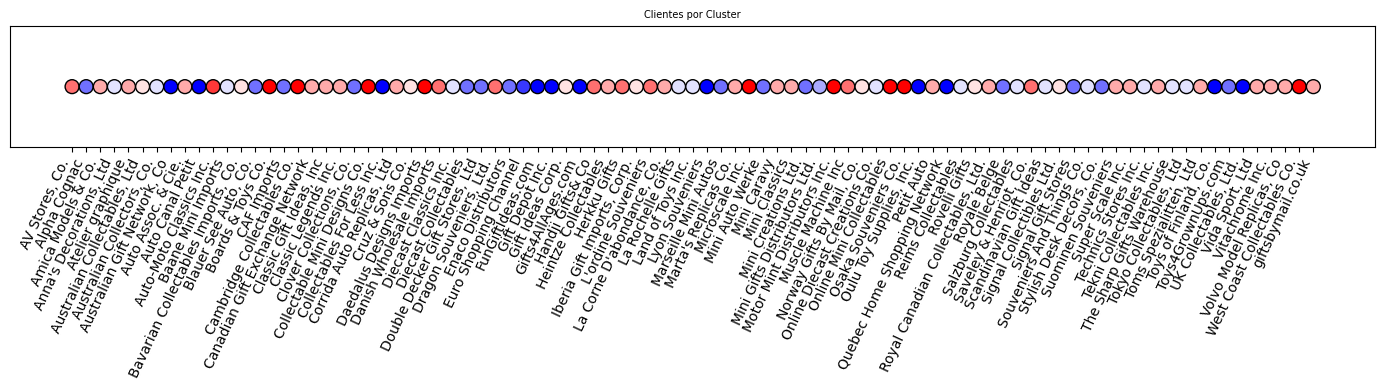

In [19]:
submission["CUSTOMERNAME"] = submission["CUSTOMERNAME"].astype("category")

y = [1] * len(submission)

plt.figure(figsize=(14, 4))
scatter = plt.scatter(
    submission["CUSTOMERNAME"],
    y,
    c=submission["Cluster"],       # cores por cluster
    cmap="bwr",            # azul/vermelho (0/1), mas pode trocar
    s=100,                 # tamanho do ponto
    edgecolors="black"
)

plt.title("Clientes por Cluster", fontsize=7)
plt.yticks([])
plt.xticks(rotation=65, ha="right")
plt.tight_layout()
plt.show()


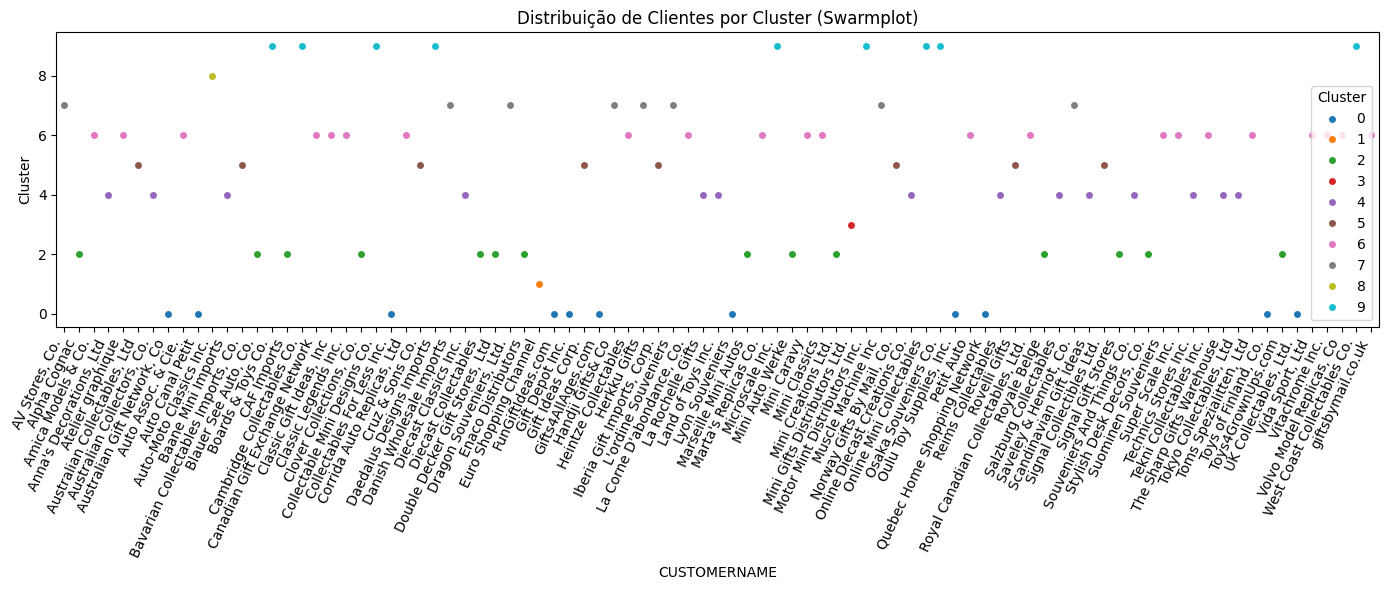

In [20]:
plt.figure(figsize=(14, 6))
sns.swarmplot(
    data=submission,
    x="CUSTOMERNAME",
    y="Cluster",
    hue="Cluster",
    palette="tab10"
)

plt.xticks(rotation=65, ha="right")
plt.title("Distribuição de Clientes por Cluster (Swarmplot)")
plt.tight_layout()
plt.show()


In [21]:
rfm.query('Cluster == 2')

,CUSTOMERNAME,Recorrência,Frequência,Monetário,Cluster
1,Alpha Cognac,675,3,70488.44,2
13,"Blauer See Auto, Co.",705,4,85171.59,2
15,CAF Imports,625,2,49642.05,2
20,"Clover Collections, Co.",659,2,57756.43,2
28,Diecast Collectables,672,2,70859.78,2
29,"Double Decker Gift Stores, Ltd",670,2,36019.04,2
31,Enaco Distributors,659,3,78411.86,2
46,Marseille Mini Autos,757,3,74936.14,2
49,Mini Auto Werke,717,3,52263.90,2
52,Mini Creations Ltd.,595,3,108951.13,2


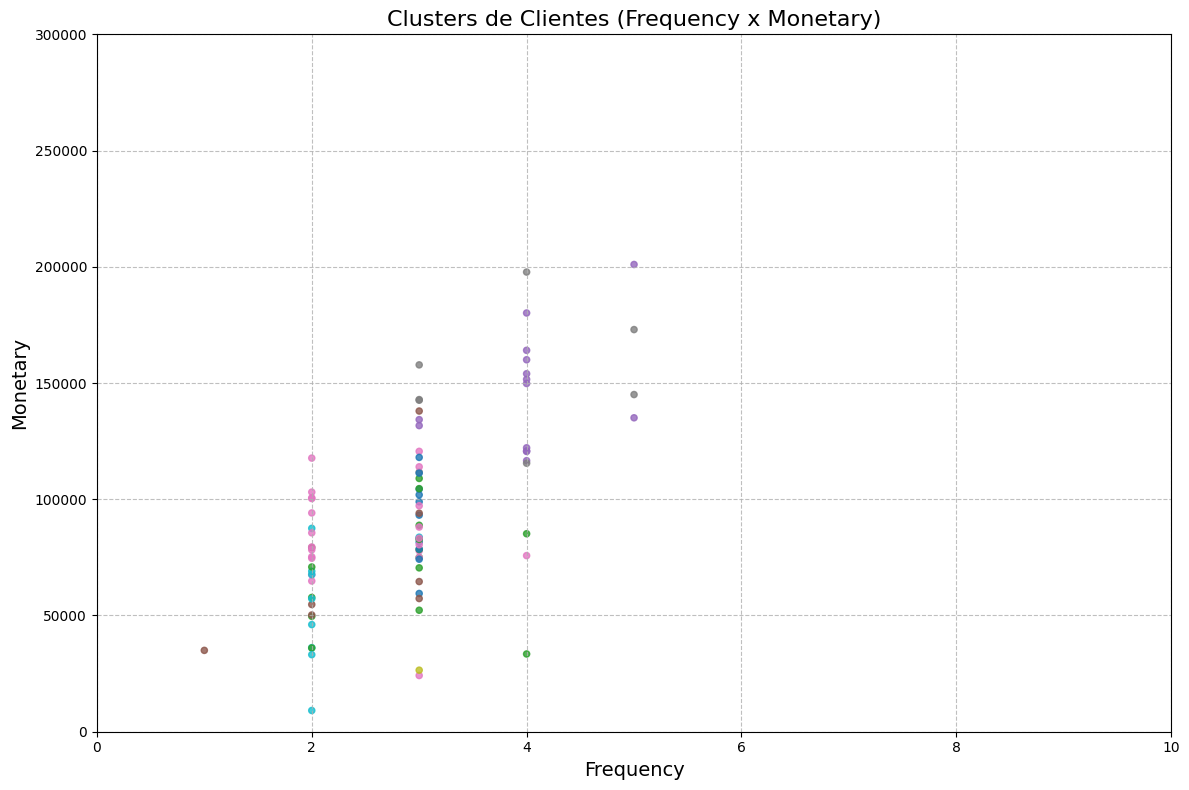

In [27]:
plt.figure(figsize=(12, 8))
cmap = plt.get_cmap("tab10")

scatter = plt.scatter(
    rfm["Frequência"],
    rfm["Monetário"],
    c=rfm["Cluster"],
    cmap=cmap,
    s=20,
    alpha=0.8,
)

plt.xlabel("Frequency", fontsize=14)
plt.ylabel("Monetary", fontsize=14)
plt.title("Clusters de Clientes (Frequency x Monetary)", fontsize=16)
plt.xlim(0, 10)
plt.ylim(0, 300000)

plt.grid(True, linestyle="--", alpha=0.8)
plt.tight_layout()
plt.show()

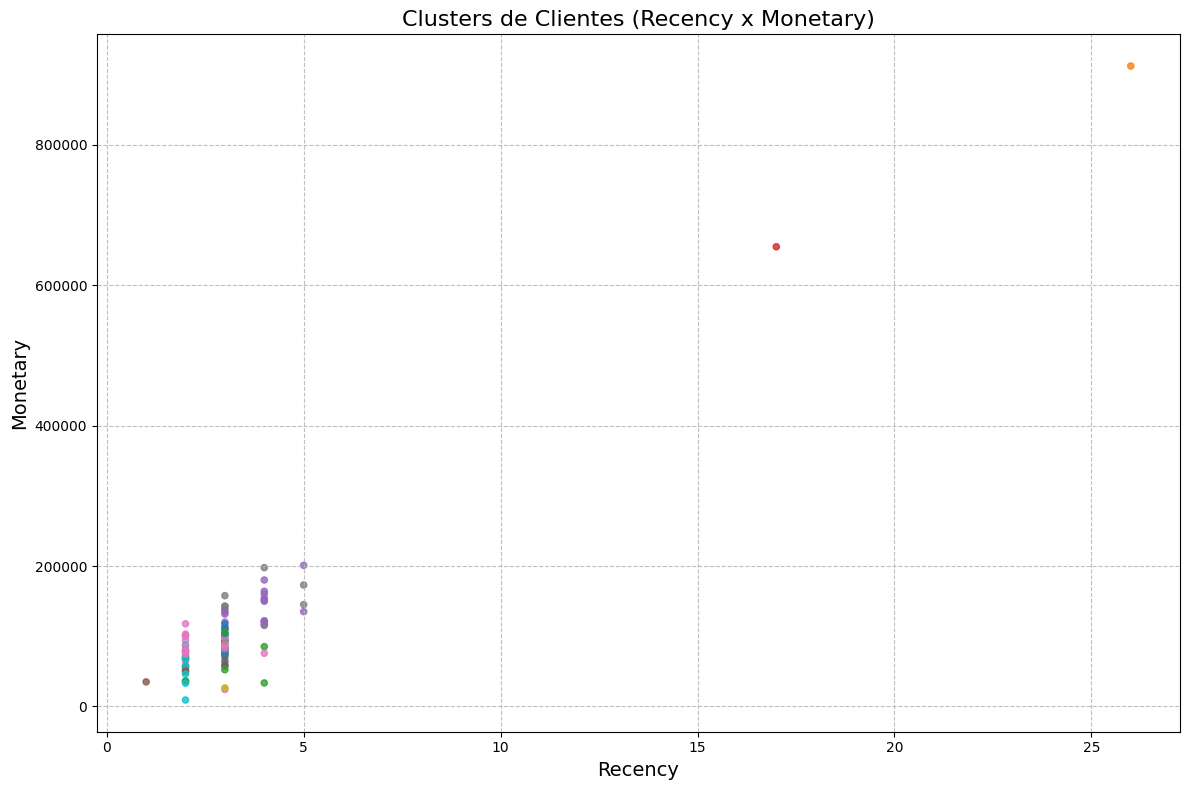

In [29]:
plt.figure(figsize=(12, 8))
cmap = plt.get_cmap("tab10")

scatter = plt.scatter(
    rfm["Frequência"],
    rfm["Monetário"],
    c=rfm["Cluster"],
    cmap=cmap,
    s=20,
    alpha=0.8,
)

plt.xlabel("Recency", fontsize=14)
plt.ylabel("Monetary", fontsize=14)
plt.title("Clusters de Clientes (Recency x Monetary)", fontsize=16)

plt.grid(True, linestyle="--", alpha=0.8)
plt.tight_layout()
plt.show()
